In [4]:
with open("/home/enzo/Documents/Zombi/ZOMBI/zombi-rs/rustree/species_tree_test_2.tre", "r") as f:
    newick_str = f.read()
newick_str
from ete3 import Tree

In [5]:
t = Tree(newick_str, format=1)

In [28]:
len(t)

45

In [6]:
import rustree

species_tree = rustree.parse_species_tree(newick_str)

In [30]:
species_tree

Simulated 10000 gene trees in 0.0033655166625976562 seconds.


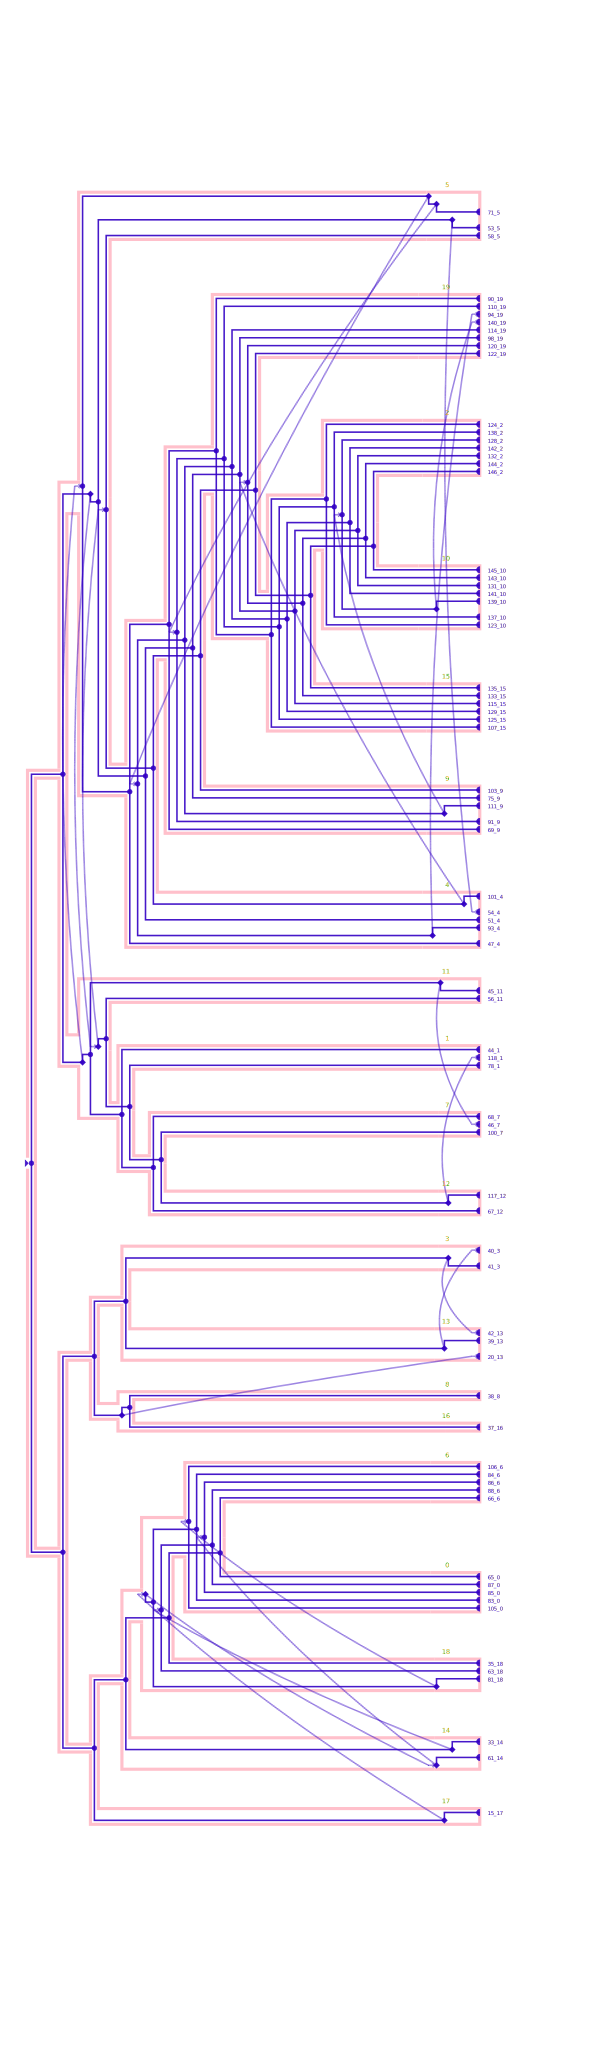

In [15]:
import time
start_time = time.time()
species_tree = rustree.simulate_species_tree(
    20,
    1,
    0)
gene_trees = species_tree.simulate_dtl_batch(
    n=10,
    lambda_d=0.0,
    lambda_t=0.5,
    lambda_l=0.01,
    seed=1234,
    transfer_alpha=10,
)
end_time = time.time()
print(f"Simulated 10000 gene trees in {end_time - start_time} seconds.")
gene_trees[0].display()

In [11]:
gene_trees[0].display()

ValueError: thirdkind failed: 
thread 'main' (399760) panicked at /home/enzo/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/light_phylogeny-2.8.6/src/arena.rs:783:43:
called `Option::unwrap()` on a `None` value
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


In [10]:
gene_trees[0].num_nodes()

95

In [35]:
from ete3 import Tree 
list_nb_nodes = []
for tree in gene_trees:
    list_nb_nodes.append((tree.num_nodes()+1)/2)  # number of leaves

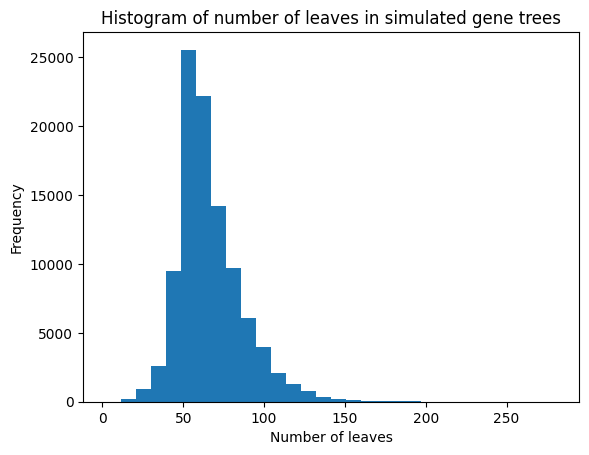

In [36]:
# Do histogram of list_nb_nodes
import matplotlib.pyplot as plt
plt.hist(list_nb_nodes, bins=30)
plt.xlabel("Number of leaves")
plt.ylabel("Frequency")
plt.title("Histogram of number of leaves in simulated gene trees")
plt.show()

In [7]:
import rustree

# species_tree = rustree.simulate_species_tree(1000, 1.0, 0.0, seed=42)
with open("/home/enzo/Documents/Zombi/ZOMBI/zombi-rs/rustree/species_tree_test.tre", "r") as f:
    newick_str = f.read()
species_tree = rustree.parse_species_tree(newick_str)

# Batch simulation (faster than loop)
gene_trees = species_tree.simulate_dtl_batch(
    n=1000,
    lambda_d=0.05,
    lambda_t=0.02,
    lambda_l=0.01,
    seed=123
)

# For a single gene tree:
gene_tree = gene_trees[0]

# Save XML to file
gene_tree.save_xml("tree.xml")

# Get DataFrame (optionally save to CSV)
df = gene_tree.to_csv("tree.csv")  # saves and returns DataFrame
df = gene_tree.to_csv()             # just returns DataFrame, no save


In [6]:
import time
start = time.time()
for i in range(1):
    gene_trees = species_tree.simulate_dtl_batch(
        n=1000,
        lambda_d=0.1,
        lambda_t=0.1,
        lambda_l=0.0,
        seed=123
    )
    gene_tree = gene_trees[0]
end = time.time()
print(f"Elapsed time: {end - start} seconds")   

Elapsed time: 4.424653768539429 seconds


In [ ]:
gene_tree.to_svg(open_browser=True)

In [ ]:
gene_tree.display()

In [ ]:
df

In [ ]:
species_tree.to_newick()